<h1 style="color:#0000FF">Kurze Einführung in NumPy</h1>
<h2 style="color:#0000FF">Numerische Mathematik / Lineare Algebra mit Python</h2>

<h2 style="color:#FF0000">Lernziele</h2>

<font color="#FF0000">
<ul>
    <li>NumPy stellt Arrays als neue Datentypen zur Verfügung - Ziel ist es Arrays zu verstehen, eigene Arrays zu erzeugen und mit Arrays zu arbeiten</li>
    <li>Die wichtigsten Befehle von NumPy kennen und anwenden können (Lineare Algebra mit Python)</li>
    <li>Spezielle Konzepte: Lambda-Funktionen (Funktionales Programmieren), Broadcasting / Vektorisierung</li>
</ul>
</font>

### Die Bibliothek **NumPy**

NumPy ist eine Programmbibliothek für Python, die eine einfache Handhabung von **Vektoren**, **Matrizen** oder generell großen **mehrdimensionalen Arrays** ermöglicht. Neben den Datenstrukturen bietet NumPy auch effizient implementierte **Funktionen für numerische Berechnungen** an.

In der Regel wird die Bibliothek wie folgt importiert (dann stehen alle Befehle der Bibliothek mittels dem Alias **np** zur Verfügung):

In [1]:
import numpy as np

### Arbeiten mit Arrays

**Eigene Arrays erzeugen**

Der wichtigste Datentyp sind die Arrays. Arrays können mit dem Befehl **np.array(...)** erzeugt werden. In den runden Klammern werden dann die Elemente des Arrays mittels eckiger Klammern angegeben. Eine einzelnes eckiges Klammerpaar erzeugt ein eindimensionales Array, mit verschachtelten eckigen Klammern können auch mehrdimensionale Arrays erzeugt werden:

In [2]:
# Beispiele von Arrays:
A = np.array([[1,2],[3,4]])
print(A)

[[1 2]
 [3 4]]


Mit der folgenden Funktion lässt sich die Ausgabe noch verschönern :-)

In [3]:
from IPython.display import display, Math

def numpy2latex( A ):
    """
    Funktion zum Umwandeln eines zweidimensionalen numpy-Arrays in einen Latex-String.
    """
    # Prüfe, ob das übergebene Array zwei Dimensionen besitzt
    if len( A.shape ) > 2:
        raise Exception( "Nur zweidimensionale Arrays erlaubt!" )
    
    # Erstelle latex-String
    latex = "\\begin{pmatrix}"
    for i in range( A.shape[0] ):
        line = ""
        for j in range( A.shape[1]-1 ):
            line += str( A[i,j] ) + " & "
        line += str( A[i,A.shape[1]-1] )
        latex += line + " \\\\ "
    latex += "\\end{pmatrix}"
    return latex

def printArray( A ):
    display(Math(numpy2latex( A )))
    
printArray( A )

<IPython.core.display.Math object>

Weitere Beispiele:

In [4]:
einDim = np.array([1,2,3,4])
print(einDim)
zweiDim = np.array([[1,2,3],[4,5,6]])
print(zweiDim)
dreiDim = np.array([[[1,2],[3,4]],[[-1,-2],[-3,-4]],[[0,0],[0,0]]])
print(dreiDim)

[1 2 3 4]
[[1 2 3]
 [4 5 6]]
[[[ 1  2]
  [ 3  4]]

 [[-1 -2]
  [-3 -4]]

 [[ 0  0]
  [ 0  0]]]


Als zusätzliches Argument beim **array**-Befehl kann noch der Datentyp angegeben werden. NumPy kennt viele verschiedene Standard-Datentypen (numerisch: uint8, uint16, uint32, uint64, int8, int16, int32, int64, float16, float32, float64, longdouble, complex64, complex128, clongdouble und sonstige: bytes, str, ...). Mittels dem Datentyp wird einerseits ein Casting (Typumwandlung) vorgenommen und es wird der Bereich (kleinste bis grösste Zahl) und die Genauigkeit vorgegeben. (Es können auch eigene Datentypen definiert und verwendet werden).

In [5]:
B = np.array([[1,2],[3,4]], dtype='float64')
print(B)
printArray(B)

[[1. 2.]
 [3. 4.]]


<IPython.core.display.Math object>

In [6]:
C = np.array([1.3,2.3,9.99], dtype='int')
print(C)

[1 2 9]


**Eigenschaften von Arrays**

Mit den Befehlen **size** (Anzahl Elemente), **shape** (Anzahl Elemente je Dimension, d.h. bei zweidimensionalen Arrays die Zeilen- und die Spaltenzahl) und **ndim** (Anzahl der Dimensionen) können erste wichtige Eigenschaften des Arrays abgefragt werden:

In [7]:
print(A.size)
print(A.shape)
print(A.ndim)
print('Das Objekt A hat {anz} Einträge, angeordnet in {nZ} Zeilen und {nS} Spalten.'.format(anz=A.size, 
                                                                                            nZ=A.shape[0], 
                                                                                            nS=A.shape[1]))

4
(2, 2)
2
Das Objekt A hat 4 Einträge, angeordnet in 2 Zeilen und 2 Spalten.


Mit dem Befehl **type(OBJEKT)** kann der Datentyp des Objekts abgefragt werden (unsere Arrays sind vom Datentyp *numpy.ndarray*) und mit **OBJEKT.dtype** der Datentyp der Elemente:

In [8]:
print(type(A))
print(A.dtype)

<class 'numpy.ndarray'>
int64


**Zugriff auf die Elemente eines Arrays**

Auf die Elemente / Einträge eines Arrays kann mittels Indizes zugegriffen werden (ACHTUNG: der Index beginnt jeweils bei Null). Der Index wird dabei in eckigen Klammern direkt hinter dem Variablennamen angegeben. Bei eindimensionalen Arrays geben wir einen Index an, bei zweidimensionalen Arrays können in der eckigen Klammer der Zeilen- und der Spaltenindex mit Komma getrennt angegeben werden (und bei höher dimensionalen Arrays kommen weitere Indizes hinzu):

In [9]:
# Erste bzw. zweite Zeile unseres Arrays A:
print(A[0])
print(A[1])
# die einzelnen Elemente des Arrays A:
print('a_11 = {}'.format(A[0,0]))
print('a_12 = {}'.format(A[0,1]))
print('a_21 = {}'.format(A[1,0]))
print('a_22 = {}'.format(A[1,1]))

[1 2]
[3 4]
a_11 = 1
a_12 = 2
a_21 = 3
a_22 = 4


Mittels **Slicing** kann auch auf Bereiche in einem Array zugegriffen werden. Dabei funktioniert das Slicing mittels der beiden folgenden Varianten:

* [start:stop]: Angabe des Startindex ('start') und des Stopindex ('stop') werden alle Elemente von Startindex (mit) bis Stopindex (ohne) ausgewählt.

* [start:stop:step]: Hier wird mit 'step' zusätzlich die Schrittweite angegeben.

In [10]:
#Bei einem eindimensionalen Array:
M = np.array([0,1,2,3,4,5,6,7,8,9])
print(M)
print(M[0])
print(M[1:5])
print(M[1:9:2])

[0 1 2 3 4 5 6 7 8 9]
0
[1 2 3 4]
[1 3 5 7]


In [11]:
#Bei einem zweidimensionalen Array:
M = np.array([[0,1,2,3,4,5],[6,7,8,9,10,11],[12,13,14,15,16,17]])
print(M)
print(M[0,0])
print(M[1:2,1:4])
print(M[0:2,2:5])

[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]
 [12 13 14 15 16 17]]
0
[[7 8 9]]
[[ 2  3  4]
 [ 8  9 10]]


Beim **Slicing** kenn man auch die Indexangabe ohne Start- und Stopindex (also nur den Doppelpunkt). Dies bewirkt das alle Zeilen bzw. Spalten ausgewählt werden (**Achtung: wenn wir bei einem zweidimensionalen Array eine ganze Zeile bzw. eine ganze Spalte Lesen, so entsteht dadurch ein eindimensionales Array!**):

In [12]:
#eine ganze Zeile (Zeilenindex ist 1 und bei den Spalten werden alle genommen)
print(M[1,:])
#eine ganze Spalte (alle Zeilen und die Spalte mit Index 1)
print(M[:,1])
#alles ausser die letzte Spalte:
print(M[:,0:5])

[ 6  7  8  9 10 11]
[ 1  7 13]
[[ 0  1  2  3  4]
 [ 6  7  8  9 10]
 [12 13 14 15 16]]


Zudem können wir bei der Angabe der Indizes auch mit negativen Werten arbeiten:

In [13]:
#Element in der letzten Zeile / letzten Spalte:
print(M[-1,-1])
#letzte Zeile:
print(M[-1,:])
#letzte Spalte:
print(M[:,-1])
#Alles bis auf die letzte Spalte:
print(M[:,:-1])

17
[12 13 14 15 16 17]
[ 5 11 17]
[[ 0  1  2  3  4]
 [ 6  7  8  9 10]
 [12 13 14 15 16]]


**Views und Copy**

Die Arrays können (z.B. Anwendungen Data Science) können unter umständen sehr gross sein. Aus diesem Grund wird in vielen Fällen nicht mit den Daten der Arrays sondern mit den Referenzen (Adressen) auf den Speicherort operiert. Sei z.B. A ein Array und wird die Zuweisung B = A vorgenommen. So wird nicht eine Kopie des Arrays A angelegt und unter B gespeichert, sondern die Variablen A und B zeigen beide auf den gleichen Speicherbereich (dort wo ursprünglich A abgelegt war). Dies kann zu unschönen Effekten führen, wird nun B verändert, so hat dies automatisch auch Auswirkungen auf A. Dies geschieht auch, wenn wir nur einen Bereich eines Arrays unter einer neuen Variablen speichern (man nennt dies auch einen **View**). Hier einige Beispiele:nämlich  kopiert 

In [14]:
#Die "Kopie" von A und somit auch A wird verändert:
print(A)
C = A
C[0,0] = -13
print(A)

[[1 2]
 [3 4]]
[[-13   2]
 [  3   4]]


In [15]:
#Eine "View" von M wird verändert und dadurch auch M:
print(M)
C = M[0:2,:]
print(C)
C[1,1] = 0
print(M)

[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]
 [12 13 14 15 16 17]]
[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]
[[ 0  1  2  3  4  5]
 [ 6  0  8  9 10 11]
 [12 13 14 15 16 17]]


Um die obigen Effekte zu vermeiden, kann durch die Angabe von **OBJEKT.copy()** eine echte Kopie erzwungen werden!

In [16]:
#Mit copy():
print(A)
C = A.copy()
C[0,0] = 42
print(C)
print(A)

[[-13   2]
 [  3   4]]
[[42  2]
 [ 3  4]]
[[-13   2]
 [  3   4]]


In [17]:
#Mit copy():
print(M)
C = M.copy()[0:2,:]
print(C)
C[1,1] = 999
print(C)
print(M)

[[ 0  1  2  3  4  5]
 [ 6  0  8  9 10 11]
 [12 13 14 15 16 17]]
[[ 0  1  2  3  4  5]
 [ 6  0  8  9 10 11]]
[[  0   1   2   3   4   5]
 [  6 999   8   9  10  11]]
[[ 0  1  2  3  4  5]
 [ 6  0  8  9 10 11]
 [12 13 14 15 16 17]]


**Vordefinierte Arrays**

Wir können auch mittels Befehlen (**zeros()**, **ones()**, **eye()**, **diag()**, ...) spezielle Matrizen (in einer gewünschten Grösse) erzeugen:

In [18]:
#2x5-Matrix mit lauter Nullen:
null = np.zeros((2,5))
print(null)
#3x2-Matrix mit Einern:
eins = np.ones((3,2))
print(eins)
#3x3 Einheitsmatrix:
einheit = np.eye(3)
print(einheit)
#5x5 Matrix mit 5, 4, 3, 2, 1 auf der Diagonalen:
diag = np.diag([5,4,3,2,1])
print(diag)
#2*10-Matrix mit Zufallszahlen:
zufall = np.random.random((2,10))
print(zufall)

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
[[1. 1.]
 [1. 1.]
 [1. 1.]]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
[[5 0 0 0 0]
 [0 4 0 0 0]
 [0 0 3 0 0]
 [0 0 0 2 0]
 [0 0 0 0 1]]
[[0.18085192 0.03555841 0.88796603 0.57370145 0.58945138 0.11674306
  0.83619775 0.41337161 0.35142826 0.77939299]
 [0.73378595 0.27466578 0.49384527 0.31478086 0.22157363 0.4772188
  0.1770059  0.58622776 0.75072772 0.59955945]]


Manchmal sind die Befehle **zeros_like**, **ones_like** und **full_like** noch nüzlich. Hier übergibt man als Argument ein Array und man erählt ein Array mit der gleichen Dimension mit lauter Nullen, Einsen, usw.:

In [19]:
print(M)
N = np.zeros_like(M)
print(N)
O = np.ones_like(M)
print(O)
F = np.full_like(B,1.2345)
print(F)

[[ 0  1  2  3  4  5]
 [ 6  0  8  9 10 11]
 [12 13 14 15 16 17]]
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]
[[1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]]
[[1.2345 1.2345]
 [1.2345 1.2345]]


Analog zum Befehl **range** (erzeugt eine Liste) gibt es in NumPy den Befehl **arange** um ein Array mit einer Zahlenfolge zu füllen. Der Syntax von **arange** ist analog zu demjenigen von **range**:

In [20]:
#Variante 1 - Anzahl Werte ab 0:
vek1 = np.arange(20)
print(vek1)
#Variante 2 - Start- und Stopwert (inkl. Start-, ohne Stopwert)
vek2 = np.arange(2,15)
print(vek2)
#Variante 3 - Start-, Stopwert und Schrittweite (inkl. Start-, ohne Stopwert)
vek3 = np.arange(-3,3.1,0.5)
print(vek3)
#Zweidimensionale Arrays mit reshape (siehe nächster Block)
M = np.arange(9).reshape(3,3)
print(M)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
[ 2  3  4  5  6  7  8  9 10 11 12 13 14]
[-3.  -2.5 -2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5  2.   2.5  3. ]
[[0 1 2]
 [3 4 5]
 [6 7 8]]


**Arrays aus bestehenden Arrays zusammensetzen und der Befehl reshape()**

Oft werden Arrays aus vorhandenen Arrays zsammengesetzt!

Die beiden Befehle **vstack()** und **hstack()** können wir nutzen, um Arrays vertikal bzw. horizontal aneinander zu hängen (Achtung: die Dimensionen müssen passen!). Beispiele:

In [21]:
print(A)
V = np.vstack((A,A))
print(V)
H = np.hstack((A,A))
print(H)

[[-13   2]
 [  3   4]]
[[-13   2]
 [  3   4]
 [-13   2]
 [  3   4]]
[[-13   2 -13   2]
 [  3   4   3   4]]


Sehr nützlich kann der Befehl **reshape()** sein. Hiermit können die Daten eines Arrays neu angeordnet werden. Die Anzahl der Einträge im Befehl ergibt die Dimension des neuen Arrays (ein Eintrag => eindimensional, zwei Einträge => zweidimensional, usw). Die übergebenen Werte geben an, wieviele Element in der entsprechenden Dimension angeordnet werden sollen. Ein Beispiel: 

In [22]:
P = np.array([[1,2,3,4],[5,6,7,8],[9,10,11,12],[13,14,15,16]])
print(P)
eindim = P.reshape(-1)
print(eindim)
print(eindim.shape)
zweidim = P.reshape(2,8)
print(zweidim)
print(zweidim.shape)
dreidim = P.reshape(2,2,4)
print(dreidim)
print(dreidim.shape)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
(16,)
[[ 1  2  3  4  5  6  7  8]
 [ 9 10 11 12 13 14 15 16]]
(2, 8)
[[[ 1  2  3  4]
  [ 5  6  7  8]]

 [[ 9 10 11 12]
  [13 14 15 16]]]
(2, 2, 4)


Achtung: Es wird mit **reshape()** keine Kopie angelegt sondern nur ein neuer **View** definiert!

In [23]:
zweidim[0,0] = -1
print(zweidim)
print(zweidim.base)
zweidim = np.array(P.reshape(8,2))
zweidim[0,1] = -13
print(P)
print(zweidim)

[[-1  2  3  4  5  6  7  8]
 [ 9 10 11 12 13 14 15 16]]
[[-1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]
[[-1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]
[[ -1 -13]
 [  3   4]
 [  5   6]
 [  7   8]
 [  9  10]
 [ 11  12]
 [ 13  14]
 [ 15  16]]


**Iteration über alle Elemente eines Arrays**

Möchten wir auf alle Elemente eines Arrays zugreifen, können wir dies mit verschachtelten **for**-Schleifen machen **Achtung:** wenn möglich auf for-Schleifen verzichten (die Verarbeitung ist extrem langsam)!):

In [24]:
A = np.array([[1,2,3],[4,5,6],[7,8,9]])
z,s = A.shape
for zeile in range(z):
    for spalte in range(s):
        print('Element in der {i}-ten Zeile und {j}-ten Spalte ist gleich {a}'.format(i=zeile, j=spalte, a=A[zeile,spalte]))

Element in der 0-ten Zeile und 0-ten Spalte ist gleich 1
Element in der 0-ten Zeile und 1-ten Spalte ist gleich 2
Element in der 0-ten Zeile und 2-ten Spalte ist gleich 3
Element in der 1-ten Zeile und 0-ten Spalte ist gleich 4
Element in der 1-ten Zeile und 1-ten Spalte ist gleich 5
Element in der 1-ten Zeile und 2-ten Spalte ist gleich 6
Element in der 2-ten Zeile und 0-ten Spalte ist gleich 7
Element in der 2-ten Zeile und 1-ten Spalte ist gleich 8
Element in der 2-ten Zeile und 2-ten Spalte ist gleich 9


In [25]:
A = np.array([[1,2,3],[4,5,6],[7,8,9]])
for zeile in A:
    for element in zeile:
        print(element)

1
2
3
4
5
6
7
8
9


### Rechnen mit Arrays

**Arithmetische Operationen**

Wir können (gleichdimensionale) Arrays addieren und wir können Arrays mit Zahlen multiplizieren (entsprechen den Matrizenoperationen der linearen Algebra):

In [26]:
A = np.array([[1,2,3],[2,3,4]])
B = np.array([[1,3,5],[2,4,6]])
C = A+B
print(C)

[[ 2  5  8]
 [ 4  7 10]]


In [27]:
D = 5*C
print(D)

[[10 25 40]
 [20 35 50]]


Wir können auch weitere Operationen ausführen - diese entsprechen aber nicht den Rechenregeln der linearen Algebra (die Operationen werden elementweise ausgeführt, was teilweise auch sehr nützlich ist!):

In [28]:
#Von jedem Element der Matrix A wird 4 abgezogen:
print(A-4)
#Die Elemente werden elementweise multipliziert:
print(A*B)
#Von jedem Element wird der Kehrwert berechnet:
print(1/A)
#Jedes Element wird quadriert:
print(A**2)
#Von jedem Element wird der natürliche Logarithmus berechnet:
print(np.log(A))

[[-3 -2 -1]
 [-2 -1  0]]
[[ 1  6 15]
 [ 4 12 24]]
[[1.         0.5        0.33333333]
 [0.5        0.33333333 0.25      ]]
[[ 1  4  9]
 [ 4  9 16]]
[[0.         0.69314718 1.09861229]
 [0.69314718 1.09861229 1.38629436]]


**Vergleichsoperationen und logische Operationen**

Werden Arrays mit Zahlen bzw. mit anderen Arrays (Dimension muss übereinstimmen) verglichen, so wird elementweise verglichen und jeder Vergleich liefert ein **True** oder ein **False** (man erhält also als Resultat wieder ein Array mit lauter Wahrheitswerten):

In [29]:
A = np.array([[1,2,3],[4,5,6],[7,8,9]])
print(A>=4)
B = np.array([[1,2],[3,4],[5,6]])
C = np.array([[2,1],[2,1],[2,1]])
print(B>=C)

[[False False False]
 [ True  True  True]
 [ True  True  True]]
[[False  True]
 [ True  True]
 [ True  True]]


Arrays mit Wahrheitswerten können mittels den logischen Operationen (elementweise) verrechnet werden. Dazu verwendet man die Befehle **logical_and()** (UND-Verknüpfung), **logical_or()** (Oder-Verknüpfung) und **logical_NOT()** (Negation):

In [30]:
K = A<8
G = A>=3
print(np.logical_and(K,G))
print(np.logical_or(K,G))
print(np.logical_not(K))

[[False False  True]
 [ True  True  True]
 [ True False False]]
[[ True  True  True]
 [ True  True  True]
 [ True  True  True]]
[[False False False]
 [False False False]
 [False  True  True]]


Im weiteren kennt NumPy die Befehle:

* **isclose()**: Vergleicht die Inhalte zweier Arrays elementweise ob die Abstände zwischen den Elementen kleiner einer vorgegebenen Toleranz ist (gibt ein gleichdimensionales Array mit Wahrheitswerten zurück),

* **allclose()**: Wie beim letzten Befehl, liefert aber nur einen Wahrheitswert (True wenn alle Elemente nahe beieinander liegen),

* **equal()**, **array_equal()**: Prüft auf Gleichheit (**equal** ist analog zu A==B und liefert ein Array als Resultat und **array_equal** liefert einen Wahrheitswert),

* **not_equal()**: Analog zu A!=B,

* **isnan()**: Prüft elementweise ob die Elemente eines Arrays **NaN** (Not a Number) sind,

* **isreal()**, **iscomplex()**: Prüft auf reelle bzw. komplexe Elemente,

* **greater()**, **greater_equal()**, **less()**, **less_equal()**: Analog zu den Vergleichsoperatoren.

* **any()**, **all()**: Prüft elementweise, ob die Elemente als wahr (ungleich 0) gewertet werden. Bei **any** bekommt man ein Array mit Wahrheitswerten und bei **all** nur einen Wahrheitswert.

In [31]:
A = np.array([[1,2],[3,4]])
invA = np.linalg.inv(A)
print(A@invA)
print(np.isclose(A@invA,np.eye(2)))
print(np.allclose(A@invA,np.eye(2)))
print(np.equal(A@invA,np.eye(2)))
print(np.array_equal(A@invA,np.eye(2)))

[[1.0000000e+00 0.0000000e+00]
 [8.8817842e-16 1.0000000e+00]]
[[ True  True]
 [ True  True]]
True
[[ True  True]
 [False False]]
False


### Minimum, Maximum, Durchschnitt und weiteres (Reduktionsfunktionen)

NumPy kennt viele Befehle um spezielle Werte (Minimum, Maximum, verschiedenste statistische Kenngrössen, usw.) aus den Elementen eines Arrays zu extrahieren. Dabei unterscheiden wir (bei zweidimensionalen Arrays) folgende Varianten:

* **axis=0**: Berechnung erfolgt Zeilenweise (Resultat ist ein eindimensionales Array)

* **axis=1**: Berechnung erfolgt Spaltenweise (Resultat ist ein eindimensionales Array)

* **axis=None**: Berechnung erfolgt über alle Elemente des Arrays (ein Wert als Resultat)

Die Angabe von **axis** ist ein zusätzliches Attribut, welches man bei den nachfolgenden Befehlen angeben kann (Standardmässig ist axis=None gesetzt). Hier einige dieser Reduktionsfunktionen:

* **min()**, **max()**: Kleinstes bzw. grösstes Element
* **argmin()**, **argmax()**: Liefert den Index des kleinsten bzw. grössten Elements
* **mean()**: Mittelwert
* **std()**, **var()**: Standardabweichung und Varianz (Achtung: Standardmässig wird durch die Anzahl der Daten (n) dividiert - möchte man durch (n-1) dividieren, muss der Freiheitsgrad (**ddof**) auf 1 gesetzt werden!)
* **sum()**, **prod()**: Summe bzw. Produkt der Elemente

Hier einige Beispiele:

In [32]:
#Array mit Werten / Daten erzeugen:
data = np.random.randint(low=0, high=100, size=(6,4))
print(data)
#Minimum bestimmen
print(data.min())               #gesamtes Array
print(data.min(axis=0))         #Spaltenweise
print(data.min(axis=1))         #Zeilenweise
#Position des Minimums
print(data.argmin())            #gesamtes Array
print(data.argmin(axis=0))      #Spaltenweise
print(data.argmin(axis=1))      #Zeilenweise
#Standardabweichung (empirisch)
print(data.std(ddof=1))         #gesamtes Array
print(data.std(axis=0,ddof=1))  #Spaltenweise
print(data.std(axis=1,ddof=1))  #Zeilenweise

[[24 63 23 20]
 [58 94 68 63]
 [77 22 10 13]
 [15 53 66  4]
 [41 85 10 88]
 [77 27 37 85]]
4
[15 22 10  4]
[20 58 10  4 10 27]
15
[3 2 2 3]
[3 0 2 3 2 1]
29.347956253066144
[26.43230347 29.42561243 26.25007936 37.68686774]
[20.40424792 16.02862024 31.41655614 29.69287232 37.44329045 28.76919649]


### Lineare Algebra

Zweidimensionale Arrays sind die Matrizen der linearen Algebra und NumPy beherscht natürlich auch die Lineare Algebra!

Bei den arithmetischen Operationen mit Arrays haben wir schon die Addition von Arrays und die Multiplikation eines Arrays mit einer Zahl kennengelernt. Diese beiden Operationen entsprechen den beiden Matrizenoperationen der Linearen Algebra.

Im weiteren gibt es in der linearen Algebra das Produkt zweier Matrizen. Dieses Produkt kann in Numpy mit dem Befehl **matmul()** berechnet werden (in neueren Versionen können Matrizen auch mit dem Operationszeichen **@** multipliziert werden und es gibt auch noch den Befehl **dot()** als Alternative zum Befehl matmul).  

In [33]:
A = np.array([[1,2,3],[4,5,6]])
B = np.array([[1,2],[3,4],[5,6]])
print(np.matmul(A,B))
print(A@B)
print(A.dot(B))
print(np.dot(A,B))

[[22 28]
 [49 64]]
[[22 28]
 [49 64]]
[[22 28]
 [49 64]]
[[22 28]
 [49 64]]


Hier weitere Befehle von NumPy mit Matrizen:

* Transponieren einer Matrix: **OBJEKT.transpose()**, **OBJEKT.T**, **np.transpose(OBJEKT)**:

In [34]:
#Transponieren:
print(A.T)
#print(np.transpose(A))
#print(A.transpose())

[[1 4]
 [2 5]
 [3 6]]


* Determinante und Rang einer Matrix: **np.linalg.det(OBJEKT)** für die Determinante einer quadratischen Matrix und **np.linalg.matrix_rank(OBJEKT)** um den Rang zu bestimmen:

In [35]:
M = np.array([[1,1,1],[1,2,2],[1,2,3]], dtype='float')
print(np.linalg.det(M))
print(np.linalg.matrix_rank(M))

1.0
3


* Inverse einer Matrix: **np.linalg.inv(OBJEKT)** berechnet die Inverse einer regulären (quadratischen) Matrix und **np.linalg.pinv(OBJEKT)** berechnet die Pseudo-Inverse (nach *Moore-Penrose*) einer beliebigen Matrix:

In [36]:
M_inv = np.linalg.inv(M)
print(M_inv)
print(M@M_inv)
A_pinv = np.linalg.pinv(A)
print(A_pinv)
print(A@A_pinv)

[[ 2. -1.  0.]
 [-1.  2. -1.]
 [ 0. -1.  1.]]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
[[-0.94444444  0.44444444]
 [-0.11111111  0.11111111]
 [ 0.72222222 -0.22222222]]
[[1.00000000e+00 2.22044605e-16]
 [0.00000000e+00 1.00000000e+00]]


* Lineare Gleichungssysteme: **np.linalg.solve(A,b)** berechnet die "exakte" Lösung des regulären linearen Gleichungssystems $A\cdot\vec{x}=\vec{b}$:

In [37]:
A = np.array([[1,2],[3,-1]])
b = np.array([7,0])
print(np.linalg.solve(A,b))

[1. 3.]


* Norm (Betrag) eines Vektors bzw. einer Matrix: Mit dem Befehl **np.linalg.norm()** können wir den Betrag / die Norm von Vektoren (eindimensionales Array) bestimmen. Standardmässig wird die Eulidische Norm (Wurzel aus der Summe aller Komponentenquadrate) verwendet. Mit der zusätzlichen Angabe des Parameters **ord** können auch andere Normen berechnet werden. Ist das Argument des **norm**-Befehls ein zweidimensionales Array, so kann die Vektornorm pro Spalte (**axis=0**) oder Zeile (**axis=1**) berechnet werden oder eine Matrizennorm (**axis=None**) wird berechnet:

In [38]:
#Betrag eines Vektors (eindimensionales Array):
v = np.array([2,-1,-2])
v_betrag = np.linalg.norm(v)
print(v_betrag)
#Vektornorm Zeilen- bzw Spaltenweise bei einer Matrix (zweidimensionales Array):
M = np.array([[2,-1,-2],[2,3,-6],[4,3,12]])
Betrag_Spaltenvektoren = np.linalg.norm(M, axis=0)
Betrag_Zeilenvektoren = np.linalg.norm(M, axis=1)
print(Betrag_Spaltenvektoren)
print(Betrag_Zeilenvektoren)

3.0
[ 4.89897949  4.35889894 13.56465997]
[ 3.  7. 13.]


* Eigenwerte und Eigenvektoren: Der Befehl **vals, vects = np.linalg.eig(OBJEKT)** liefert von einer quadratischen Matrix die Eigenwerte (vals) und die dazugehörigen Eigenvektoren:

In [39]:
M = np.array([[2,0,0],[0,0,1],[0,1,0]])
vals, vects = np.linalg.eig(M)
print(vals)
print(vects)
#M lässt sich diagonalisieren!
D = np.diag(vals)
V = vects
V_inv = vects.T
print(V@D@V_inv)

[ 1. -1.  2.]
[[ 0.          0.          1.        ]
 [ 0.70710678  0.70710678  0.        ]
 [ 0.70710678 -0.70710678  0.        ]]
[[2. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]


* Singulärwertzerlegung: Der Befehl **U,sigmas,Vh = np.linalg.svd(OBJEKT)** liefert von einer beliebigen Matrix die Singulärwertzerlegung. Die Matrizen U und Vh sind orthogonale (bzw. unitäre) Matrizen und die **sigmas** sind die Singulärwerte der gegebenen Matrix:

In [40]:
M = np.array([[3,0],[0,-4],[0,1]], dtype='float')
U,s,Vh = np.linalg.svd(M, full_matrices=True)
print(U)
print(s)
print(Vh)
#Kontrolle der Zerlegung:
S = np.zeros_like(M)
S[:2,:2] = np.diag(s)
print(U@S@Vh)

[[ 0.          1.          0.        ]
 [-0.9701425   0.          0.24253563]
 [ 0.24253563  0.          0.9701425 ]]
[4.12310563 3.        ]
[[0. 1.]
 [1. 0.]]
[[ 3.  0.]
 [ 0. -4.]
 [ 0.  1.]]


* Faktorzerlegungen: In der linearen Algebra kennt man verschiedenste Faktorzerlegungen für Matrizen. NumPy kennt die *QR-Zerlegung* (Befehl **Q,R = np.linalg.qr(OBJEKT)**) und die *Cholesky-Zerlegung* (Befehl **L=np.linalg.cholesky(OBJEKT)** (weitere Zerlegungen findet man in der Bibliothek **SciPy**):

In [41]:
#Bespiel Cholesky-Zerlegung:
A = np.array([[1,2,3,4],[4,3,2,1],[1,0,0,1]])
Q, R = np.linalg.qr(A)
print(Q)
print(R)
print(Q@R)
#Bespiel Cholesky-Zerlegung:
A = np.array([[1,1,0],[1,3,0],[0,0,5]])
L = np.linalg.cholesky(A)
print(L)
print(L@L.T)

[[-0.23570226  0.84119102  0.48666426]
 [-0.94280904 -0.07647191 -0.32444284]
 [-0.23570226 -0.53530338  0.81110711]]
[[-4.24264069 -3.29983165 -2.59272486 -2.12132034]
 [ 0.          1.45296631  2.37062925  2.75298881]
 [ 0.          0.          0.81110711  2.43332132]]
[[ 1.00000000e+00  2.00000000e+00  3.00000000e+00  4.00000000e+00]
 [ 4.00000000e+00  3.00000000e+00  2.00000000e+00  1.00000000e+00]
 [ 1.00000000e+00 -1.11022302e-16 -4.14614138e-16  1.00000000e+00]]
[[1.         0.         0.        ]
 [1.         1.41421356 0.        ]
 [0.         0.         2.23606798]]
[[1. 1. 0.]
 [1. 3. 0.]
 [0. 0. 5.]]


### Lambda-Funktionen

Lambda-Funktionen sind Funktionen ohne Namen (anonyme Funktionen). Der Syntax einer solchen Lambda-Funktion sieht folgendermassen aus:

**lambda argumente: ausdruck**

Hier zuerst eine "normale" Funktion in Python (Binomialkoeffizient):

In [42]:
def my_fun(n,k):
    res = 1.0
    for i in range(k):
        res *= (n-i)/(i+1)
    return res

print(my_fun(0,0))
print(my_fun(1,0),' ',my_fun(1,1))
print(my_fun(2,0),' ',my_fun(2,1),' ',my_fun(2,2))
print(my_fun(3,0),' ',my_fun(3,1),' ',my_fun(3,2),' ',my_fun(3,3))
print(my_fun(4,0),' ',my_fun(4,1),' ',my_fun(4,2),' ',my_fun(4,3),' ',my_fun(4,4))

1.0
1.0   1.0
1.0   2.0   1.0
1.0   3.0   3.0   1.0
1.0   4.0   6.0   4.0   1.0


Die gleiche Funktion als Lambda-Funktion:

In [43]:
import math

myfun = lambda n,k: math.factorial(n)/math.factorial(k)/math.factorial(n-k)

print(myfun(10,8))

45.0


Lambda-Funktionen kommen häufig dann zum Einsatz, wenn Funktionen eine Funktion als Argument enthalten. Z.B. bei den folgenden Python-Funktionen:

**filter()**: Die von Python zur Verfügung gestellte Funktion filtert aus einer Liste Elemente heraus, welche eine bestimmte Bedingung erfüllen, und erzeugt mit diesen Elementen eine neue Liste (eigentlich einen Iterator). Der Syntax sieht wie folgt aus:

**filter(condition_function,data)**

Hier ein Beispiel:

In [44]:
# Beispiel zum Befehl filter:
#
# Aus der Liste quad mit den Quadratzahlen von 0 bis 625 sollen die geraden Quadratzahlen rausgefiltert werden.
# Dazu wird die Lambda-Funktion
#
# lambda x: x%2==0
#
# als Argument an die Filterfunktion übergeben. Die Lambda-Funktion liefert den Wahrheitswert True, wenn das 
# Argument eine Gerade Zahl ist!
#
quad = [i**2 for i in range(1,26)]
print(quad)
quad_gerade = list(filter(lambda x: x%2==0, quad))
print(quad_gerade)

[1, 4, 9, 16, 25, 36, 49, 64, 81, 100, 121, 144, 169, 196, 225, 256, 289, 324, 361, 400, 441, 484, 529, 576, 625]
[4, 16, 36, 64, 100, 144, 196, 256, 324, 400, 484, 576]


**map()**: Die map-Funktion von Python stellt einen Substitutionsmechanismus zur Verfügung. Das erste Argument der map-Funktion ist eine Funktion und im zweiten Argument stehen die Werte, welche in der Funktion eingesetzt werden sollen. Syntax:

**map(function,data)**

Ein Beispiel:

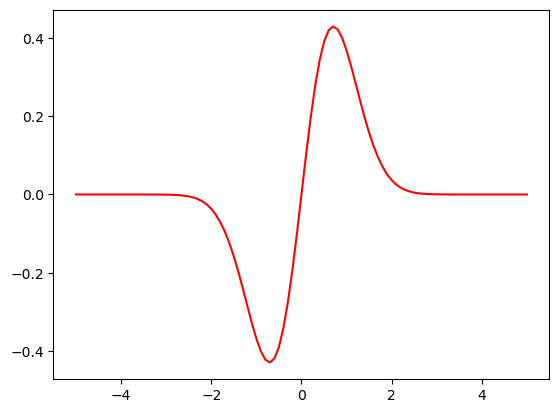

In [45]:
# Beispiel zum Befehl map:
#
# Zu den Werten der unabhängigen Variablen x aus der Liste xx werden die Funktionswerte yy zur Funktion y=f(x)=e^(-x^2)
# berechnet. Das berechnen der Funktionswerte erfolgt mit der map-Funktion. Dazu wird in der map-Funktion als erstes
# Argument die Funktionsvorschrift übergeben und als zweites Argument die x-Werte. Die Angabe der Funktionsvorschrift 
# kann durch die folgende Lambda-Funktion erfolgen: 
#
# lambda x: np.exp(-x**2)
#
import numpy as np
#xx = np.arange(-5,5.1,0.1)
xx = np.array(np.arange(-5,5.1,0.1))
#print(xx)
yy = np.array(list(map(lambda x: x*np.exp(-x**2), xx)))
#print(yy)

# Visualisierung:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
f = ax.plot(xx, yy,'r-')
plt.show()

**reduce()**: Die redude-Funktion wendet eine Berechnungsvorschrift auf alle Elemente einer Liste an und liefert einen Zahlenwert als Resultat. Dabei wird die Berechnungsvorschrift zuerst auf die ersten beiden Einträge angewandt anschliessend wird dieses Resultat mit dem dritten Element verrechnet usw.. Syntax:

**reduce(function,data)**

In [46]:
# Beispiel zum Befehl reduce:
#
# Summe aller Binomialkoeffizienten einer Zeile im Pascal'schen Dreieck.
#
# In einem ersten Schritt wird die n-te Zeile des Pascal'schen Dreieck berechnet (z.B. mit der map-Funktion)!
#
# Anschliessend wird mit der reduce-Funktion die Summe der Elemente berechnet!
#
import math
import functools
n = 10
zeile_n = list(map(lambda k:math.factorial(n)/math.factorial(k)/math.factorial(n-k), range(n+1)))
print(zeile_n)

summe_n = functools.reduce(lambda x,y:x+y, zeile_n)
print(summe_n)

[1.0, 10.0, 45.0, 120.0, 210.0, 252.0, 210.0, 120.0, 45.0, 10.0, 1.0]
1024.0


### Broadcasting mit Arrays

**Broadcasting** beschreibt eine Technik wie NumPy arithmetische Operationen mit Arrays unterschiedlicher Grösse ausführt. Wie wir weiter oben schon gesehen haben, können wir zwei Arrays mittels arithmetischer Operationen (+, -, *, /) miteinander verechnen - dies geschieht bei Arrays mit gleicher Dimension elementweise. Beim Broadcasting versucht Python diese Rechenoperationen auch bei Arrays unterschiedlicher Grösse durchzuführen! Dabei versucht Python die Dimension des kleineren Arrays an diejenige des grösseren Arraxs anzupassen, so dass die Dimensionen passen und eine elementweise Berechnung möglich ist. Dies ist eine Art von **Vektorisierung** - dadurch können die Rechenoperationen in **C** (vorkompiliert) ausgeführt werden und man kann dadurch oft auf die Verwendung von Schleifen in Python (interpretiert) verzichten. In vielen Fällen erhält man mit Broadcasting viel effizientere Algorithmen!

Hier ein Beispiel: Gegeben sei der folgende Datensatz $X$ ($n=20$) mit vier Attributen. Wir suchen den Korrelationskoeffizienten zwischen jeweils zwei Attributen. Der Korrelationskoeffizient kann nach der folgenden Formel berechnet werden ($x$ und $y$ sind zwei Attribute, $\bar{x}$, $\bar{y}$ die Mittelwerte und $s_x$, $s_y$ die Standardabweichungen der beiden Attribute):

$$r=\frac{\sum_{k=1}^{n}\left(x_k-\bar{x}\right)\left(y_k-\bar{y}\right)}{\left(n-1\right)\cdot s_x\cdot s_y}$$

In [47]:
#Daten:
X = np.array([[0.51, 0.87, -1.08,  0.1],
              [0.77, 0.11, -2.01, 0.78],
              [0.87, 0.3, -2.03, 0.45],
              [0.01, 0.47, 0.19, 0.66],
              [0.31, 0.67, -0.37, 1.05],
              [0.96, 0.26, -1.6, 0.55],
              [0.51, 0.7, -1.16, 0.48],
              [0.32, 0.66, -0.89, 0.15],
              [0.54, 0.18, -0.85, 0.27],
              [0.22, 0.32, -0.22, 0.44],
              [0.81, 0.89, -1.61, 0.66],
              [0.34, 0.08, -0.68, 0.71],
              [0.54, 0.75, -1.42, 0.42],
              [0.01, 0.06, -0.07, 0.05],
              [0.67, 0.73, -1.01, 0.07],
              [0.21, 0.74, -0.65, 0.26],
              [0.93, 0.41, -1.98, 0.95],
              [0.37, 0.99, -0.78, 0.14],
              [0.75, 0.45, -1.58, 0.85],
              [0.76, 0.19, -1.97, -0.01]])
#Mittelwerte:
X_quer = X.mean(axis=0)
print(X_quer)
#Standardabweichungen:
std = X.std(axis=0,ddof=1)
print(std)

[ 0.5205  0.4915 -1.0885  0.4515]
[0.29110452 0.29533701 0.67655688 0.31951073]


Berechnung mit for-Schleifen für die ersten beiden Spalten:

In [48]:
#Mit for-Schleife
r_12 = 0
x = X[:,0]
y = X[:,1]
x_quer = X_quer[0]
y_quer = X_quer[1]
sx = std[0]
sy = std[1]
n, s = X.shape
for i in range(n):
    r_12 += (x[i]-x_quer)*(y[i]-y_quer)
r_12 /= (n-1)*sx*sy
print(r_12)

-0.06220673419705163


Kleines Programm, welches von einer Datenmatrix alle Korrelationskoeffizienten mittels for-Schleifen berechnet und diese in einer Matrix zurück gibt (auch Mittelwert und Standardabweichung werden mit Schleifen berechnet):

In [49]:
def cor_for(X):
    z,s = X.shape
    #Mittelwerte
    X_quer = np.zeros(s)
    for i in range(s):
        for j in range(z):
            X_quer[i] += X[j,i]
        X_quer[i] /= z
    #Standardabweichungen
    X_std = np.zeros(s)
    for i in range(s):
        for j in range(z):
            X_std[i] += (X[j,i]-X_quer[i])**2
        X_std[i] = np.sqrt(X_std[i]/(z-1))
    #Korrelationskoffizienten
    cor = np.zeros((s,s))
    for i in range(s):
        for j in range(s):
            r = 0
            for k in range(z):
                r += (X[k,i]-X_quer[i])*(X[k,j]-X_quer[j])
            cor[i,j] = r/((z-1)*X_std[i]*X_std[j]) 
    return cor

In [50]:
%timeit cor_for(X)
print(cor_for(X))          

348 μs ± 14 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
[[ 1.         -0.06220673 -0.93374939  0.23114692]
 [-0.06220673  1.          0.07605955 -0.13104163]
 [-0.93374939  0.07605955  1.         -0.15055233]
 [ 0.23114692 -0.13104163 -0.15055233  1.        ]]


Die obige Berechnung der Korrelationskoffizienten lässt sich (schneller, eleganter) ohne for-Schleifen lösen. Dazu werden die Daten zentriert (von jeder Datenspalte wird der Mittelwert abgezogen) und anschliessend standardisiert (jede Datenspalte wird durch die Standardabweichung dividiert). Dies kann effizient mittels Broadcasting gelösst werden. Die Datenmatrix ist hier eine $20\times 4$ Matrix und die Mittelwerte sind ein eindimensionales Array mit vier Elementen. Wenn wir in Python diese beiden Opjekte subtrahieren, wird aus dem eindimensionalen Array mit den Mittelwerten eine $20\times 4$-Matrix gebilted, in welcher in den einzelnen Spalten jeweils der Mittelwert der entsprechenden Spalte steht (alles gleiche Werte in der Spalte) und anschliessend kann die Subtraktion mit zwei Matrizen gleicher Grösse durchgeführt werden (dies bewirkt, dass bei den Elementen jeder Spalte der Datenmatrix der entsprechende Mittelwert der Spalte abgezogen wird!). Analog verfahren wir mit den Standardabweichung (es wird die zentrierte Datenmatrix durch ein eindimensionales Array mit den Standardabweichungen der einzelnen Spalten dividiert - wieder kommt hier das Broadcasting zum Einsatz!). 

Nun reduziert sich die Berechnung auf ($S$ sei die zentrierte und standardisierte Datenmatrix: 

$$r_{ij}=\frac{\sum_{k=1}^{n}\left(x_{ki}-\bar{x_i}\right)\left(x_{kj}-\bar{x_[i]}\right)}{\left(n-1\right)\cdot s_{i}\cdot s_{j}}=\frac{1}{n-1}\sum_{k=1}^{n}S_{ki}S_{kj}$$

Die Summe kann nun mittels einem Skalarprodukt berechnet werden (als Matrizenprodukt): 


In [51]:
z,s = X.shape
Xs = (X-X.mean(axis=0))/X.std(axis=0, ddof=1)
cor = Xs.T@Xs/(z-1)
print(cor)

[[ 1.         -0.06220673 -0.93374939  0.23114692]
 [-0.06220673  1.          0.07605955 -0.13104163]
 [-0.93374939  0.07605955  1.         -0.15055233]
 [ 0.23114692 -0.13104163 -0.15055233  1.        ]]


Als Funktion (wobei für die Berechnung von den Mittelwerten und Standardabweichungen ebenfalls mittels Broadcasting und Skalarprodukt gearbeitet wird):

In [52]:
def cor_broadcasting(X):
    z,s = X.shape
    #Mittelwerte
    X_quer = np.reshape(np.ones((1,z))@X/z,-1)
    #Standardabweichungen
    X_std = np.reshape(np.sqrt(np.ones((1,z))@(X-X_quer)**2/(z-1)),-1)
    #Korrelation:
    Xs = (X-X_quer)/X_std
    cor = Xs.T@Xs/(z-1)
    return cor

In [53]:
%timeit cor_broadcasting(X)
print(cor_broadcasting(X))

28.9 μs ± 867 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
[[ 1.         -0.06220673 -0.93374939  0.23114692]
 [-0.06220673  1.          0.07605955 -0.13104163]
 [-0.93374939  0.07605955  1.         -0.15055233]
 [ 0.23114692 -0.13104163 -0.15055233  1.        ]]


Die Berechnung mittels Broadcasting ist also etwa zehn mal schneller - hier noch der Vergleich mit der in NumPy eingebauten Funktion ($20\times 4$-Matrix):

In [54]:
print('Zeitaufwand mit for-Schleifen:')
%timeit cor_for(X)
print(cor_for(X))
print('Zeitaufwand mit Broadcasting:')
%timeit cor_broadcasting(X)
print(cor_broadcasting(X))
print('Zeitaufwand direkte Berechnung in NumPy:')
%timeit np.corrcoef(X.T)
print(np.corrcoef(X.T))

Zeitaufwand mit for-Schleifen:
329 μs ± 11.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
[[ 1.         -0.06220673 -0.93374939  0.23114692]
 [-0.06220673  1.          0.07605955 -0.13104163]
 [-0.93374939  0.07605955  1.         -0.15055233]
 [ 0.23114692 -0.13104163 -0.15055233  1.        ]]
Zeitaufwand mit Broadcasting:
29.3 μs ± 584 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
[[ 1.         -0.06220673 -0.93374939  0.23114692]
 [-0.06220673  1.          0.07605955 -0.13104163]
 [-0.93374939  0.07605955  1.         -0.15055233]
 [ 0.23114692 -0.13104163 -0.15055233  1.        ]]
Zeitaufwand direkte Berechnung in NumPy:
60.2 μs ± 3.96 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
[[ 1.         -0.06220673 -0.93374939  0.23114692]
 [-0.06220673  1.          0.07605955 -0.13104163]
 [-0.93374939  0.07605955  1.         -0.15055233]
 [ 0.23114692 -0.13104163 -0.15055233  1.        ]]


Vergleich bei grösserer Datenmenge ($5000\times 6$-Matrix):

In [55]:
Y = np.random.random((5000,6))
print('Zeitaufwand mit for-Schleifen:')
%timeit cor_for(Y)
print('Zeitaufwand mit Broadcasting:')
%timeit cor_broadcasting(Y)
print('Zeitaufwand direkte Berechnung in NumPy:')
%timeit np.corrcoef(Y.T)
cf = cor_for(Y)
cb = cor_broadcasting(Y)
cNP = np.corrcoef(Y.T)
#print(cf)
#print(cb)
#print(cNP)
#Resultate vergleichen:
print(np.allclose(cf,cb))
print(np.allclose(cb,cNP))

Zeitaufwand mit for-Schleifen:
127 ms ± 4.3 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
Zeitaufwand mit Broadcasting:
1.08 ms ± 28.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Zeitaufwand direkte Berechnung in NumPy:
403 μs ± 3.04 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
True
True


### Übungsaufgaben

**1. Aufgabe**

Zu den fünf Punkten $P_1(0,\sin(0))$, $P_2(\frac{\pi}{4},\sin(\frac{\pi}{4}))$, $P_3(\frac{\pi}{2},\sin(\frac{\pi}{2}))$, $P_4(\frac{3\pi}{4},\sin(\frac{3\pi}{4}))$ und $P_5(\pi,\sin(\pi))$ soll das Interpolationspolynom $4$-ten Grades ($y=p_4(x)=a_4x^4+a_3x^3+a_2x^2+a_1x+a_0$) gefunden werden.

[0.         0.78539816 1.57079633 2.35619449 3.14159265]
[0.00000000e+00 7.07106781e-01 1.00000000e+00 7.07106781e-01
 1.22464680e-16]


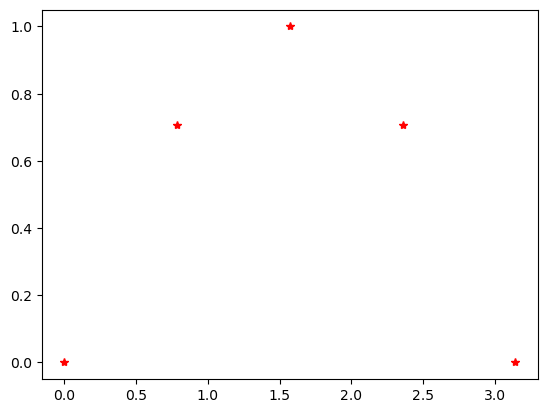

In [56]:
x = np.arange(0,5*np.pi/4,np.pi/4)
print(x)
y = np.sin(x)
print(y)
import matplotlib.pyplot as plt
plt.plot(x,y,'r*')

In [57]:
#Lineares Gleichungssystem (Punkte im Ansatz einsetzen):
x_vec = x.reshape(5,1)
M = np.hstack((x_vec**4,x_vec**3,x_vec**2,x_vec,np.ones_like(x_vec)))
print(M)
b = y.reshape(5,1)
print(b)

[[ 0.          0.          0.          0.          1.        ]
 [ 0.38050426  0.48447307  0.61685028  0.78539816  1.        ]
 [ 6.08806819  3.87578459  2.4674011   1.57079633  1.        ]
 [30.82084521 13.08077297  5.55165248  2.35619449  1.        ]
 [97.40909103 31.00627668  9.8696044   3.14159265  1.        ]]
[[0.00000000e+00]
 [7.07106781e-01]
 [1.00000000e+00]
 [7.07106781e-01]
 [1.22464680e-16]]


In [58]:
#Koeffizienten (Lösung des linearen Gleichungssystems):
lsg = np.linalg.solve(M,b)
print(lsg)

[[ 0.03757577]
 [-0.23609551]
 [ 0.05828771]
 [ 0.98196839]
 [ 0.        ]]


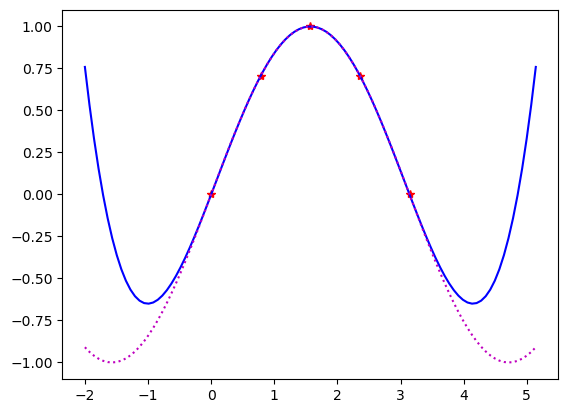

In [59]:
xx = np.linspace(-2,np.pi+2,100)
yy = lsg[0]*xx**4+lsg[1]*xx**3+lsg[2]*xx**2+lsg[3]*xx+lsg[4]*np.ones_like(xx)
y_sin = np.sin(xx)
plt.plot(x,y,'r*',xx,yy,'b-',xx,y_sin,'m:')

**2. Aufgabe**

Gegeben seien die untenstehenden ($n=30$) Datenpunkte. Wir suchen eine Approximation mittels einem Polynom $2$-ten Grades ($y=p_2(x)=a_2x^2+a_1x+a_0$). Wenn wir die gegebenen Punkte in diesem Ansatz einsetzen, so bekommen wir ein lineares Gleichungssystem mit $30$ Gleichungen und $3$ Unbekannten (die Lösung ist eine leere Menge). Wird dieses lineare Gleichungssystem:

$$X\cdot\vec{a}=\left(\begin{array}{3}\vec{x}^{2}&\vec{x}^{1}&\vec{x}^{0}\end{array}\right)\cdot\left(\begin{array}{c}a_2\\a_1\\a_0\end{array}\right)=\vec{y}$$

beidseitig mit $X^T$ (von Links) multipliziert, so erhält man das Normalensystem. Dieses neue lineare Gleichungssystem $X^T\cdot X\cdot\vec{x}=X^T\cdot\vec{y}$ ist ein (reguläres) $3\times 3$-System und die dazugehörige Lösung ist die (im Sinne der Minimierung der Summe der Fehlerquadrate) beste Lösung zum ursprünglichen widersprüchlichen System:

$\vec{a}=\left(\begin{array}{c}a_2\\a_1\\a_0\end{array}\right)=\left(X^T\cdot X\right)^{-1}\cdot X^T\cdot \vec{y}$

Bestimme das Approximationspolynom und stelle die Punkte und den Graphen des Polynoms grafisch dar.

In [60]:
data = np.array(
    [[-10. , -21.2], [ -9.5, -12.3], [ -9. ,  -4.2], [ -8.5,   3.7], [ -8. ,   8.2], [ -7.5,   9.7],
     [ -7. ,  16.2], [ -6.5,  27.1], [ -6. ,  27.6], [ -5.5,  23.7], [ -5. ,  27.7], [ -4.5,  29.2],
     [ -4. ,  34.7], [ -3.5,  39.1], [ -3. ,  32.7], [ -2.5,  37.4], [ -2. ,  42. ], [ -1.5,  37.5],
     [ -1. ,  35.9], [ -0.5,  35.9], [  0. ,  36.6], [  0.5,  28.4], [  1. ,  30.2], [  1.5,  28.2],
     [  2. ,  21.1], [  2.5,  25.4], [  3. ,  17.1], [  3.5,  16.3], [  4. ,   3.7], [  4.5,  -4.1]]
)

In [61]:
n,k = data.shape
x = data[:,0].reshape(n,1)
y = data[:,1].reshape(n,1)
X = np.hstack((x**2,x,x**0))
lsg = np.linalg.inv(X.T@X)@X.T@y
print(lsg[0,0])
print('y=p_2(x)={a2:.3f}*x+{a1:.3f}*x+{a0:.3f}'.format(a2=lsg[0,0],a1=lsg[1,0],a0=lsg[2,0]))

-0.8897723661210868
y=p_2(x)=-0.890*x+-3.614*x+34.573


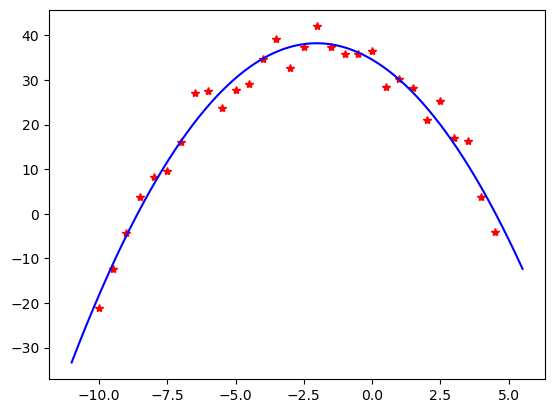

In [62]:
xx = np.linspace(x.min()-1,x.max()+1.01,1000)
yy = lsg[0,0]*xx**2+lsg[1,0]*xx+lsg[2,0]*np.ones_like(xx)
import matplotlib.pyplot as plt
plt.plot(x,y,'r*',xx,yy,'b-')